# **Context**

Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.
They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

Downloading Dataset

In [ ]:
import pandas as pd
import warnings
#warnings.filterwarnings("ignore")
!wget "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv" -O "Jamboree_Admission.csv"

--2024-09-09 16:58:26--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 13.224.9.129, 13.224.9.103, 13.224.9.181, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|13.224.9.129|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16176 (16K) [text/plain]
Saving to: ‘Jamboree_Admission.csv’

Jamboree_Admission. 100%[===================>]  15.80K  --.-KB/s    in 0.001s  

2024-09-09 16:58:26 (23.7 MB/s) - ‘Jamboree_Admission.csv’ saved [16176/16176]



In [ ]:
df=pd.read_csv("Jamboree_Admission.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


# **Column Profiling:**

Serial No. (Unique row ID)

GRE Scores (out of 340)

TOEFL Scores (out of 120)

University Rating (out of 5)

Statement of Purpose and Letter of Recommendation Strength (out of 5)

Undergraduate GPA (out of 10)

Research Experience (either 0 or 1)

Chance of Admit (ranging from 0 to 1)

In [ ]:
df.shape

(500, 9)

Now, let us drop the irrelevant column and check if there are any null values in the dataset

In [ ]:
df = df.drop(['Serial No.'], axis=1)
df.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


**Using Non-graphical and graphical analysis for getting inferences about variables.**
**This can be done by checking the distribution of variables of graduate applicants.**

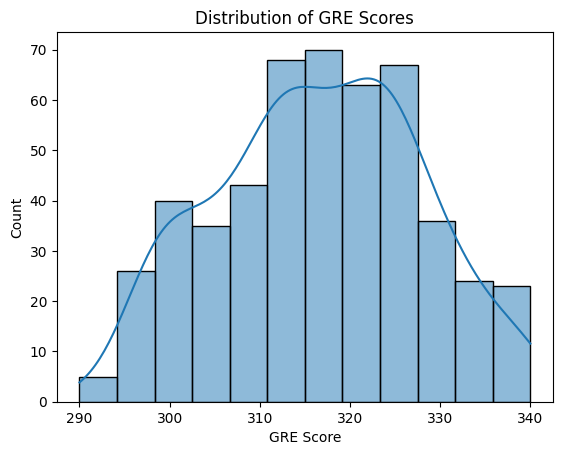

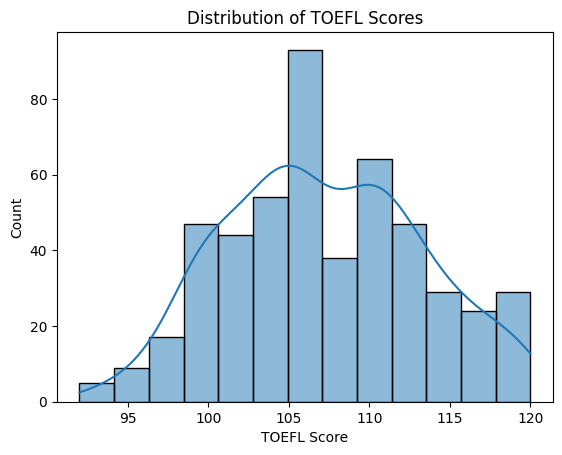

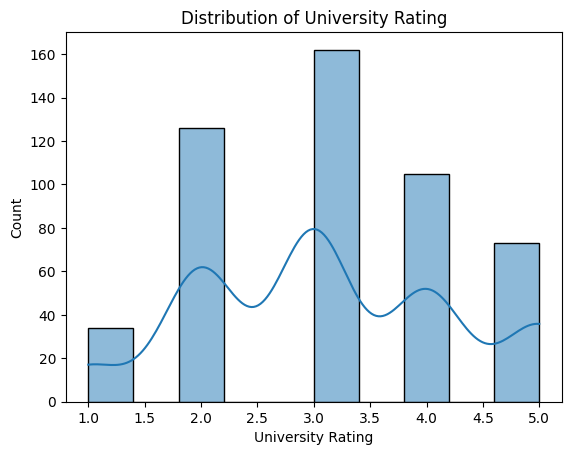

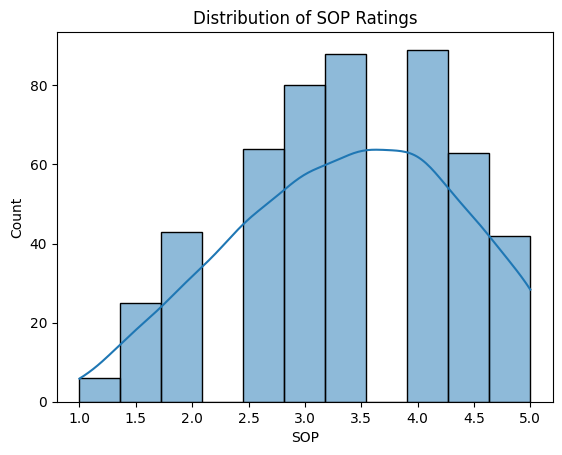

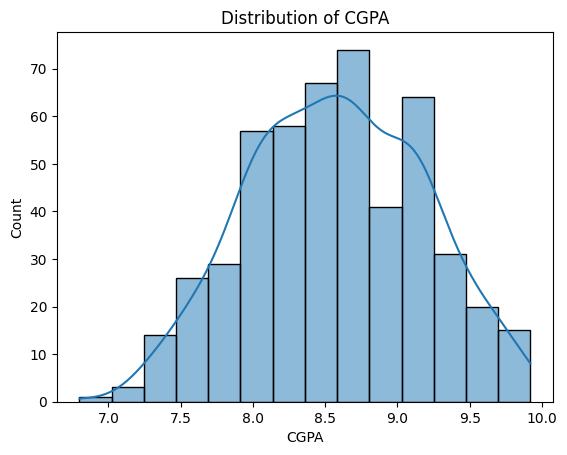

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = sns.histplot(df['GRE Score'], kde=True)
plt.title("Distribution of GRE Scores")
plt.show()
fig = sns.histplot(df['TOEFL Score'], kde=True)
plt.title("Distribution of TOEFL Scores")
plt.show()
fig = sns.histplot(df['University Rating'], kde=True)
plt.title("Distribution of University Rating")
plt.show()
fig = sns.histplot(df['SOP'], kde=True)
plt.title("Distribution of SOP Ratings")
plt.show()
fig = sns.histplot(df['CGPA'], kde=True)
plt.title("Distribution of CGPA")
plt.show()
plt.show()

Insights from the above analysis:
It is clear from the distributions, students with varied merit apply for the university.



**Understanding the relationship between different factors responsible for graduate admissions.**



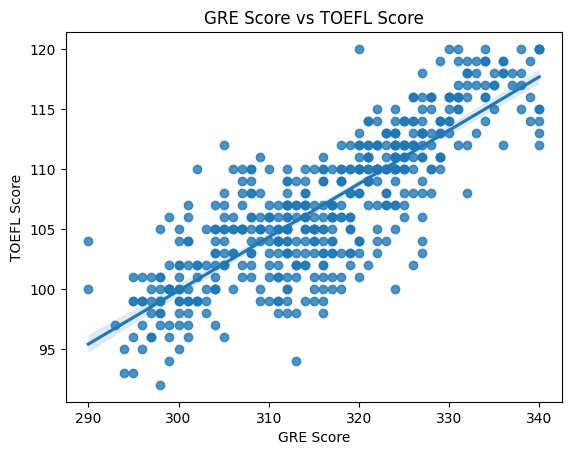

In [ ]:
fig = sns.regplot(x="GRE Score", y="TOEFL Score", data=df)
plt.title("GRE Score vs TOEFL Score")
plt.show()

People with higher GRE Scores also have higher TOEFL Scores which is justified because
both TOEFL and GRE have a verbal section which although not similar are relatable

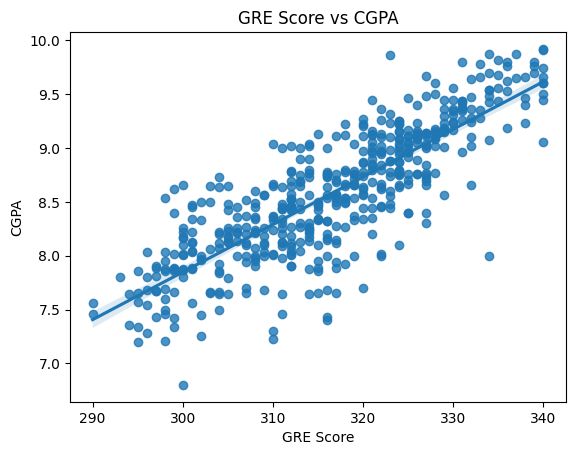

In [ ]:
fig = sns.regplot(x="GRE Score", y="CGPA", data=df)
plt.title("GRE Score vs CGPA")
plt.show()

Although there are exceptions, people with higher CGPA usually have higher GRE scores
maybe because they are smart or hard working

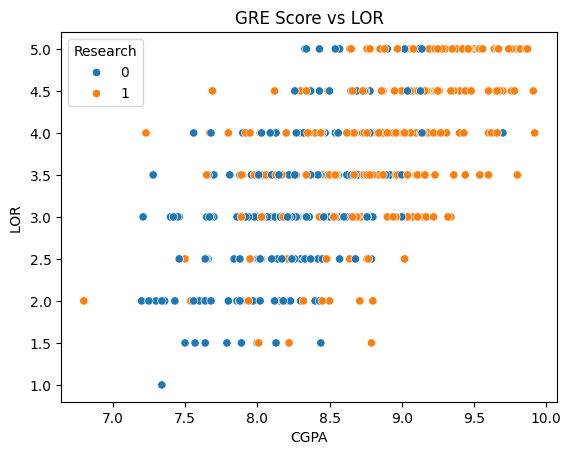

In [ ]:
fig = sns.scatterplot(x="CGPA", y="LOR ", data=df, hue="Research")
plt.title("GRE Score vs LOR")
plt.show()

LORs are not that related with CGPA so it is clear that a persons LOR is not dependent on
that persons academic excellence. Having research experience is usually related with a
good LOR which might be justified by the fact that supervisors have personal interaction
with the students performing research which usually results in good LORs

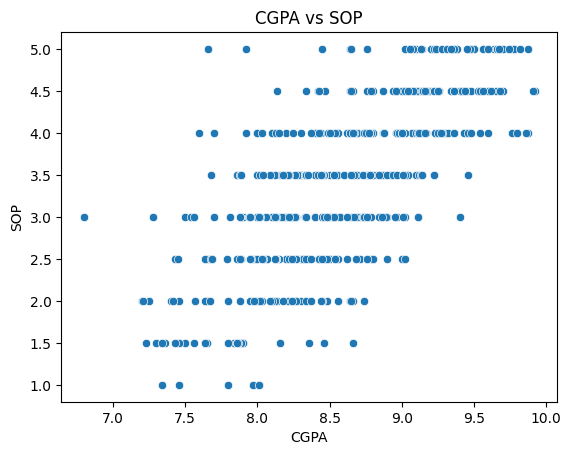

In [ ]:
fig = sns.scatterplot(x="CGPA", y="SOP", data=df)
plt.title("CGPA vs SOP")
plt.show()

CGPA and SOP are not that related because Statement of Purpose is related to academic
performance, but since people with good CGPA tend to be more hard working so they have
good things to say in their SOP which might explain the slight move towards higher CGPA
as along with good SOPs

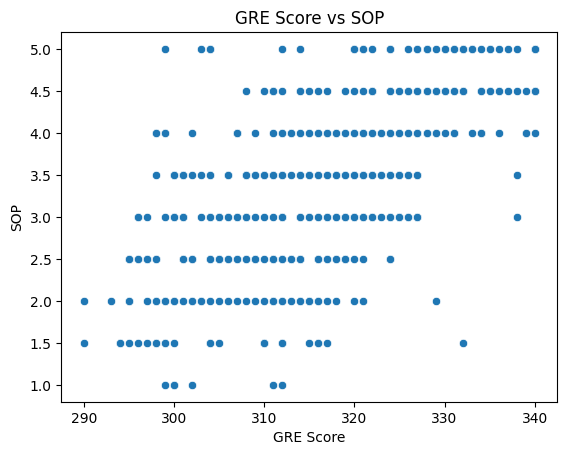

In [ ]:
fig = sns.scatterplot(x="GRE Score", y="SOP", data=df)
plt.title("GRE Score vs SOP")
plt.show()

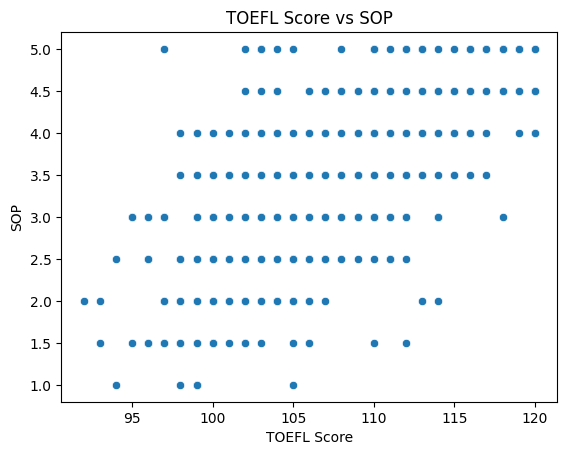

In [ ]:
fig = sns.scatterplot(x="TOEFL Score", y="SOP", data=df)
plt.title("TOEFL Score vs SOP")
plt.show()

Applicants with different kinds of SOP have different kinds of TOEFL Score. So the quality of
SOP is not always related to the applicants English skills.

**Check correlation among independent variables and how they interact with each other.**

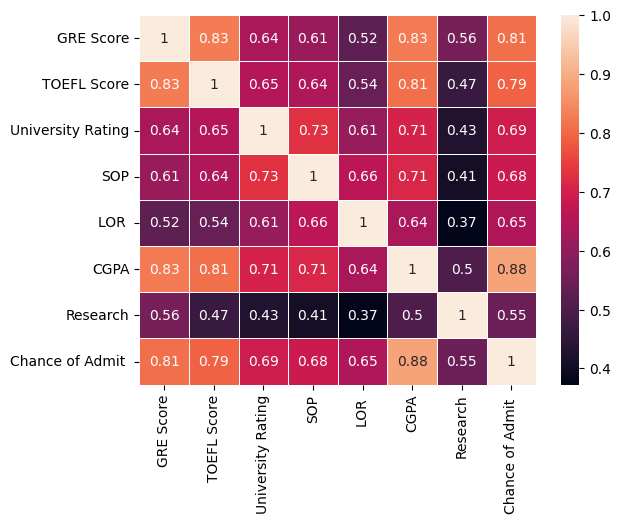

In [ ]:
import numpy as np
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')
sns.heatmap(corr, linewidths=.5, annot=True)
plt.show()

**Use Linear Regression from (Statsmodel library) and explain the results.**

Lets split the dataset with training and testing set and prepare the inputs and outputs

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(['Chance of Admit '], axis=1)
y = df['Chance of Admit ']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)


In [ ]:
y_train

,Chance of Admit
249,0.77
433,0.71
19,0.62
322,0.72
332,0.75
...,...
106,0.87
270,0.72
348,0.57
435,0.55


In [ ]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
249,321,111,3,3.5,4.0,8.83,1
433,316,111,4,4.0,5.0,8.54,0
19,303,102,3,3.5,3.0,8.50,0
322,314,107,2,2.5,4.0,8.27,0
332,308,106,3,3.5,2.5,8.21,1
...,...,...,...,...,...,...,...
106,329,111,4,4.5,4.5,9.18,1
270,306,105,2,2.5,3.0,8.22,1
348,302,99,1,2.0,2.0,7.25,0
435,309,105,2,2.5,4.0,7.68,0


In [ ]:
#Standardization
from sklearn.preprocessing import StandardScaler
X_train_columns=X_train.columns
std=StandardScaler()
X_train_std=std.fit_transform(X_train)

In [ ]:
X_train_std

array([[ 0.38998634,  0.6024183 , -0.09829757, ...,  0.56498381,
         0.4150183 ,  0.89543386],
       [-0.06640493,  0.6024183 ,  0.7754586 , ...,  1.65149114,
        -0.06785154, -1.11677706],
       [-1.25302222, -0.87691722, -0.09829757, ..., -0.52152352,
        -0.13445427, -1.11677706],
       ...,
       [-1.34430047, -1.37002906, -1.8458099 , ..., -1.60803084,
        -2.2157898 , -1.11677706],
       [-0.7053527 , -0.38380538, -0.97205374, ...,  0.56498381,
        -1.49981038, -1.11677706],
       [-0.24896144, -0.21943477, -0.97205374, ...,  0.02173015,
        -0.55072138, -1.11677706]])

In [ ]:
X_train=pd.DataFrame(X_train_std, columns=X_train_columns)

In [ ]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,0.389986,0.602418,-0.098298,0.126796,0.564984,0.415018,0.895434
1,-0.066405,0.602418,0.775459,0.633979,1.651491,-0.067852,-1.116777
2,-1.253022,-0.876917,-0.098298,0.126796,-0.521524,-0.134454,-1.116777
3,-0.248961,-0.055064,-0.972054,-0.887570,0.564984,-0.517420,-1.116777
4,-0.796631,-0.219435,-0.098298,0.126796,-1.064777,-0.617324,0.895434
...,...,...,...,...,...,...,...
395,1.120212,0.602418,0.775459,1.141162,1.108237,0.997792,0.895434
396,-0.979187,-0.383805,-0.972054,-0.887570,-0.521524,-0.600673,0.895434
397,-1.344300,-1.370029,-1.845810,-1.394754,-1.608031,-2.215790,-1.116777
398,-0.705353,-0.383805,-0.972054,-0.887570,0.564984,-1.499810,-1.116777


Lets use a bunch of different algorithms to see which model performs better

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso,Ridge,LinearRegression
from sklearn.metrics import mean_squared_error
models = [
 ['Linear Regression :', LinearRegression()],

 ['Lasso Regression :', Lasso(alpha=0.1)], #try with differen
 ['Ridge Regression :', Ridge(alpha=1.0)] #try with different
 ]
print("Results without removing features with multicollinearity ...")
for name,model in models:
 model.fit(X_train, y_train.values)
 predictions = model.predict(std.transform(X_test))
 print(name, (np.sqrt(mean_squared_error(y_test, predictions))))

Results without removing features with multicollinearity ...
Linear Regression : 0.06086588041578314
Lasso Regression : 0.12242927166741772
Ridge Regression : 0.06087507177653933


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


**Linear Regression using Statsmodel library**
Adjusted. R-squared reflects the fit of the model. R-squared values range from 0 to 1,
where a higher value generally indicates a better fit, assuming certain conditions are
met.
const coefficient is Y-intercept.
std err reflects the level of accuracy of the coefficients. The lower it is, the higher is the
level of accuracy
P >|t| is  p-value. A p-value of less than 0.05 is considered to be statistically
significant
Confidence Interval represents the range in which our coefficients are likely to fall (with
a likelihood of 95%)

In [ ]:
import statsmodels.api as sm
X_train = sm.add_constant(X_train)
X_train


,const,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,1.0,0.389986,0.602418,-0.098298,0.126796,0.564984,0.415018,0.895434
1,1.0,-0.066405,0.602418,0.775459,0.633979,1.651491,-0.067852,-1.116777
2,1.0,-1.253022,-0.876917,-0.098298,0.126796,-0.521524,-0.134454,-1.116777
3,1.0,-0.248961,-0.055064,-0.972054,-0.887570,0.564984,-0.517420,-1.116777
4,1.0,-0.796631,-0.219435,-0.098298,0.126796,-1.064777,-0.617324,0.895434
...,...,...,...,...,...,...,...,...
395,1.0,1.120212,0.602418,0.775459,1.141162,1.108237,0.997792,0.895434
396,1.0,-0.979187,-0.383805,-0.972054,-0.887570,-0.521524,-0.600673,0.895434
397,1.0,-1.344300,-1.370029,-1.845810,-1.394754,-1.608031,-2.215790,-1.116777
398,1.0,-0.705353,-0.383805,-0.972054,-0.887570,0.564984,-1.499810,-1.116777


In [ ]:
model = sm.OLS(y_train.values, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Mon, 09 Sep 2024   Prob (F-statistic):          3.41e-142
Time:                        17:38:00   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7242      0.00

Dropping "SOP" feature as its p value is very high indicating that the feature is insignificant

In [ ]:
X_train_new=X_train.drop(columns='SOP')

In [ ]:
model1=sm.OLS(y_train.values, X_train_new).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     300.4
Date:                Mon, 09 Sep 2024   Prob (F-statistic):          2.01e-143
Time:                        17:40:26   Log-Likelihood:                 561.85
No. Observations:                 400   AIC:                            -1110.
Df Residuals:                     393   BIC:                            -1082.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7242      0.00

Dropping "University Rating" feature based on the statistics summary p-value.

In [ ]:
X_train2=X_train_new.drop(columns='University Rating')

In [ ]:

model2=sm.OLS(y_train.values, X_train2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     360.8
Date:                Mon, 09 Sep 2024   Prob (F-statistic):          1.36e-144
Time:                        17:41:55   Log-Likelihood:                 561.54
No. Observations:                 400   AIC:                            -1111.
Df Residuals:                     394   BIC:                            -1087.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.7242      0.003    241.830      

**VIF(Variance Inflation Factor)**
“ VIF score of an independent variable represents how well the variable is explained by
other independent variables.
So, the closer the R^2 value to 1, the higher the value of VIF and the higher the
multicollinearity with the particular independent variable.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(dataset,col):
 dataset=dataset.drop(columns=col,axis=1)
 vif=pd.DataFrame()
 vif['features']=dataset.columns
 vif['VIF_Value']=[variance_inflation_factor(dataset.values,i) for i in range (dataset.shape[1])]
 return vif

In [ ]:
calculate_vif(X_train2,[])

,features,VIF_Value
0,const,1.000000
1,GRE Score,4.471557
2,TOEFL Score,3.540082
3,LOR,1.655867
4,CGPA,4.281365
5,Research,1.504670


VIF looks fine and hence, we can go ahead with the predictions

**Test the assumptions of linear regression:**

Multicollinearity check by VIF score

Mean of residuals

Linearity of variables (no pattern in residual plot)

Test for Homoscedasticity

Normality of residuals

In [ ]:
X_test_std= std.transform(X_test)

In [ ]:
X_test=pd.DataFrame(X_test_std, columns=X_train_columns)

In [ ]:
X_test = sm.add_constant(X_test)

In [ ]:
X_test_del=list(set(X_test.columns).difference(set(X_train2.columns)))
X_test_del

['University Rating', 'SOP']

In [ ]:
X_test_new=X_test.drop(columns=X_test_del)

In [ ]:
#Prediction from the clean model
pred = model2.predict(X_test_new)
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
print('Mean Absolute Error ', mean_absolute_error(y_test.values,pred))
print('Root Mean Square Error ', np.sqrt(mean_squared_error(y_test.values,pred)))
print('R2 Score ', r2_score(y_test.values,pred))

Mean Absolute Error  0.042923455782657785
Root Mean Square Error  0.06142491974041883
R2 Score  0.8155002070847485


**Mean of Residuals**

In [ ]:
residuals = y_test.values-pred
mean_residuals = np.mean(residuals)
print("Mean of Residuals {}".format(mean_residuals))

Mean of Residuals -0.005305947942349201


Test for Homoscedasticity

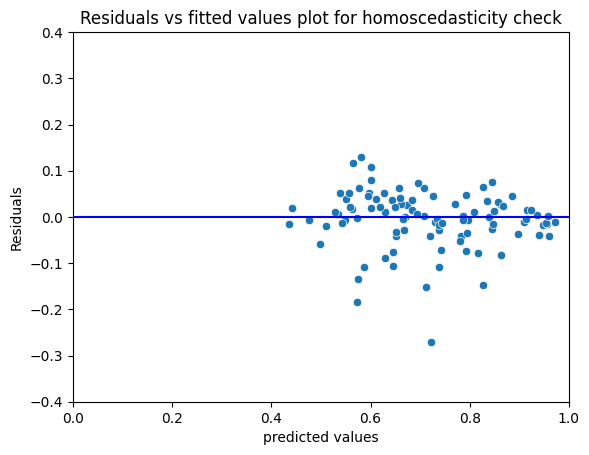

In [ ]:
p = sns.scatterplot(x=pred,y=residuals)
plt.xlabel('predicted values')
plt.ylabel('Residuals')
plt.ylim(-0.4,0.4)
plt.xlim(0,1)
p = sns.lineplot(x=[0,26], y=[0,0], color='blue')

p = plt.title('Residuals vs fitted values plot for homoscedasticity check')
plt.show()

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(residuals, X_test)
lzip(name, test)

[('F statistic', 0.5421223107289667), ('p-value', 0.9748375977319168)]

Here null hypothesis is - error terms are homoscedastic and since p-values >0.05,
we fail to reject the null hypothesis

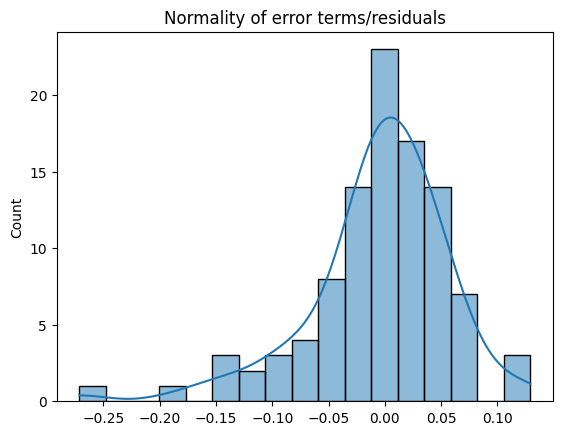

In [ ]:
p = sns.histplot(residuals,kde=True)
p = plt.title('Normality of error terms/residuals')

Text(0, 0.5, 'y_pred')

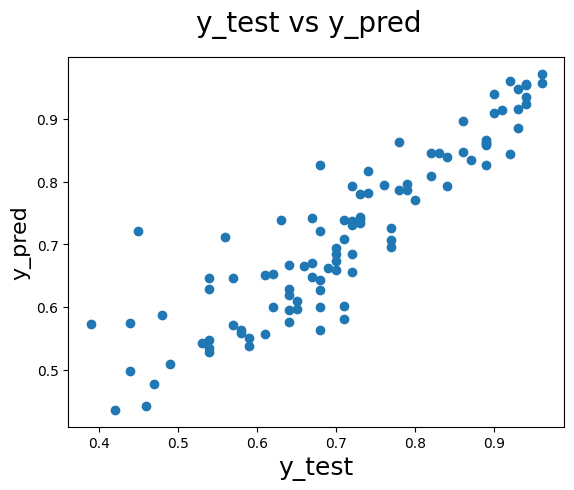

In [ ]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test.values, pred)
fig.suptitle('y_test vs y_pred', fontsize=20) # Plot head
plt.xlabel('y_test', fontsize=18) # X-label
plt.ylabel('y_pred', fontsize=16)

There are more errors when the chances of admit are less, how to fix
- Train my model more on the data points where the chances of admit are less
- Feature enginering to highlight or strengthen the datapoints where chances are less
-We can use a complex model that can identify the pattern

**Bias-Variance Tradeoff**
- Bias is as a result of over simplified model assumptions
- Variance occurs when the assumptions are too complex
- The more preferred model is one with low bias and low varinace.
- Dimensionality reduction and feature selection can decrease variance by simplifying
models.
- Similarly, a larger training set tends to decrease variance.
- For reducing Bias: Change the model, Ensure the date is truly representative(Ensure
that the training data is diverse and represents all possible groups or outcomes.),
Parameter tuning.
- The bias–variance decomposition forms the conceptual basis for regressionregularization methods such as Lasso and ridge regression.
- Regularization methods introduce bias into the regression solution that can reduce
variance considerably relative to the ordinary least squares (OLS) solution.
- Although the OLS solution provides non-biased regression estimates, the lower
variance solutions produced by regularization techniques provide superior MSE
performance.
Linear and Generalized linear models can be regularized to decrease their variance at

# **Insights & Recommendations¶**

**Insights:**

- The distribution of target variable (chances of admit) is left-skewed
Exam scores (CGPA/GRE/TOEFL) have a strong positive correlation with chance of admit.
- These variables are also highly correlated amongst themselves
- The categorical variables such as university ranking, research, quality of SOP and LOR also show an upward trend for chances of admit.
- From the model coefficients (weights), we can conclude that CGPA is the most significant predictor variable while SOP/University Rating are the least significant
- Both Linear Regression and Ridge Regression models, which are our best models, have captured upto 82% of the variance in the target variable (chance of admit). Due to high colinearity among the predictor variables, it is difficult to achieve better results.
- Other than multicolinearity, the predictor variables have met the conditions required for Linear Regression - mean of residuals is close to 0, linearity of variables, normality of residuals and homoscedasticity is established.

**Recommendations:**

- Since all the exam scores are highly correlated, it is recommended to add more independent features for better prediction.
Examples of other independent variables could be work experience, internships, mock interview performance, extracurricular activities or diversity variables
